# Introduction to Neural Networks - Project

## **Problem Statements**

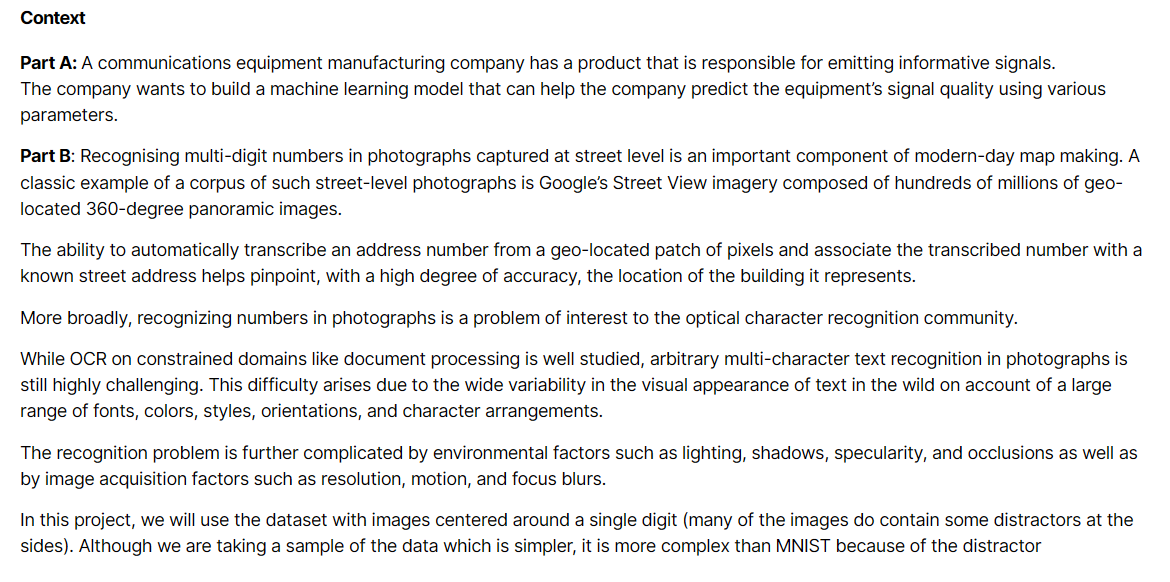

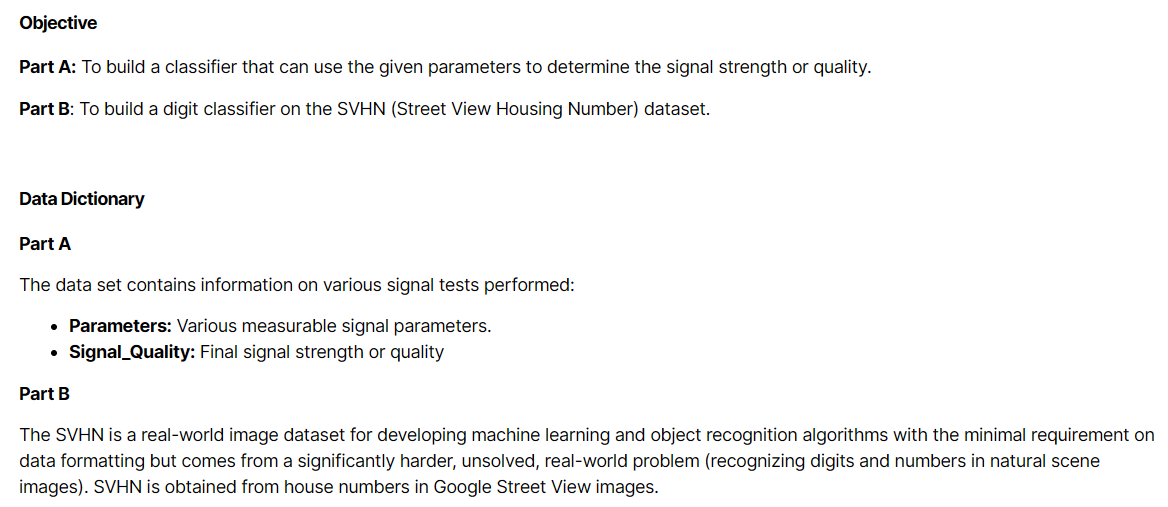

# **Part A**

## **Q1 A. Read the ‘Signals.csv’ as DataFrame and import required libraries.**

### **Importing the Required Libraries**

In [157]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import layers, models


# To supress warnings
import warnings
warnings.filterwarnings("ignore")

### **Loading the Dataset & Reading the CSV File**

In [158]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = r"/content/drive/MyDrive/NN Project Data - Signal.csv"
data = pd.read_csv(file_path)

In [160]:
# view the first 5 rows
data.head()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [161]:
# let's create a copy of the data to avoid any changes to original data
df1 = data.copy()

In [162]:
df1.head()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## **Q1 B. Check for missing values and print percentage for each attribute.**

In [163]:
print("Number of Missing Values")
df1.isnull().sum()

Number of Missing Values


,0
Parameter 1,0
Parameter 2,0
Parameter 3,0
Parameter 4,0
Parameter 5,0
Parameter 6,0
Parameter 7,0
Parameter 8,0
Parameter 9,0
Parameter 10,0


In [164]:
print("Number of Missing Values in Percentage")
round(df1.isnull().sum() / df1.isnull().count() * 100, 2)

Number of Missing Values in Percentage


,0
Parameter 1,0.0
Parameter 2,0.0
Parameter 3,0.0
Parameter 4,0.0
Parameter 5,0.0
Parameter 6,0.0
Parameter 7,0.0
Parameter 8,0.0
Parameter 9,0.0
Parameter 10,0.0


## **Q1 C. Check for presence of duplicate records in the dataset and impute with appropriate method.**

In [165]:
df1.duplicated().sum()

np.int64(240)

### Observations:

- There are 240 duplicate value in the data.
- Let's take a closer look at it.

In [166]:
df1[df1.duplicated(keep=False) == True]

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1567,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1579,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1581,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6


In [167]:
# We will drop the row which occurs second.
df = df1.drop_duplicates()

In [168]:
df.duplicated().sum()

np.int64(0)

In [169]:
print(f"Total Number of rows before drop: {df1.shape[0]}")
print(f"Total Number of rows after drop : {df.shape[0]}")

Total Number of rows before drop: 1599
Total Number of rows after drop : 1359


## **Q1 D - Visualise distribution of the target variable.**

In [170]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top
    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(12, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="deep",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = int(p.get_height())  # count of each level of the category without decimals

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


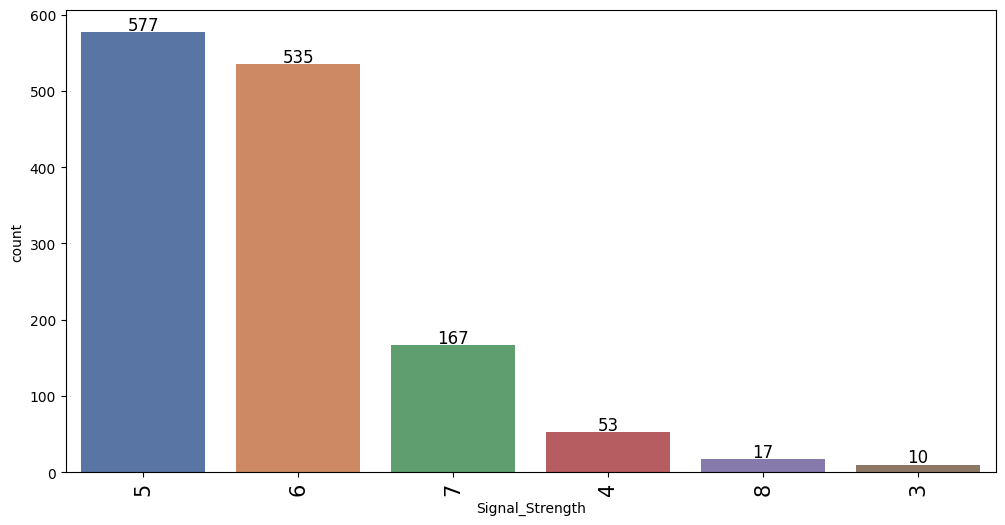

In [171]:
labeled_barplot(df, 'Signal_Strength');

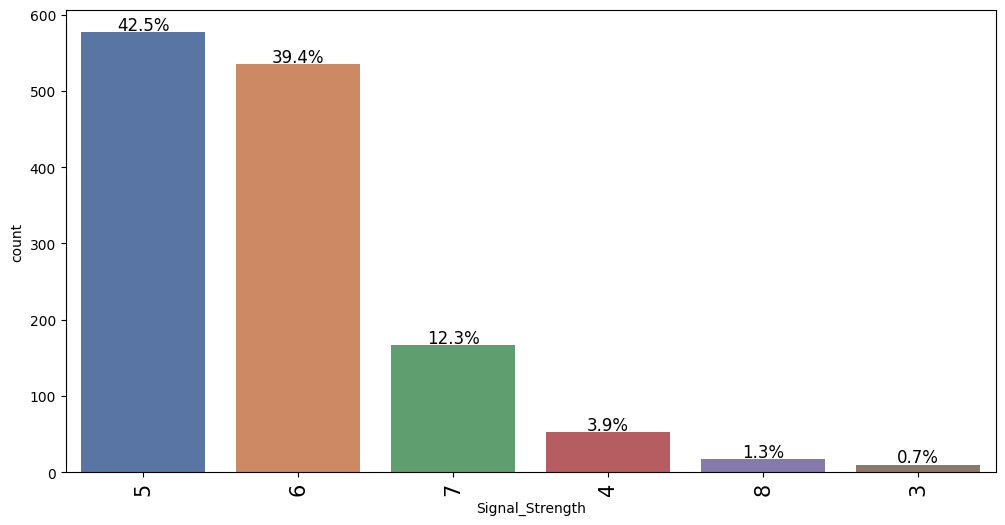

In [172]:
labeled_barplot(df, 'Signal_Strength', perc=True);

### Observations:

- The majority of observations have a Signal Strength of 5 (577, 42.5%) and 6 (535, 39.4%), while very few have a strength of 3 (10, 0.7%) or 8 (17, 1.3%).

## **Q1 E. Share insights from the initial data analysis (at least 2).**

In [173]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Parameter 1,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
Parameter 2,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
Parameter 3,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
Parameter 4,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
Parameter 5,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
Parameter 6,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
Parameter 7,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
Parameter 8,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
Parameter 9,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
Parameter 10,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


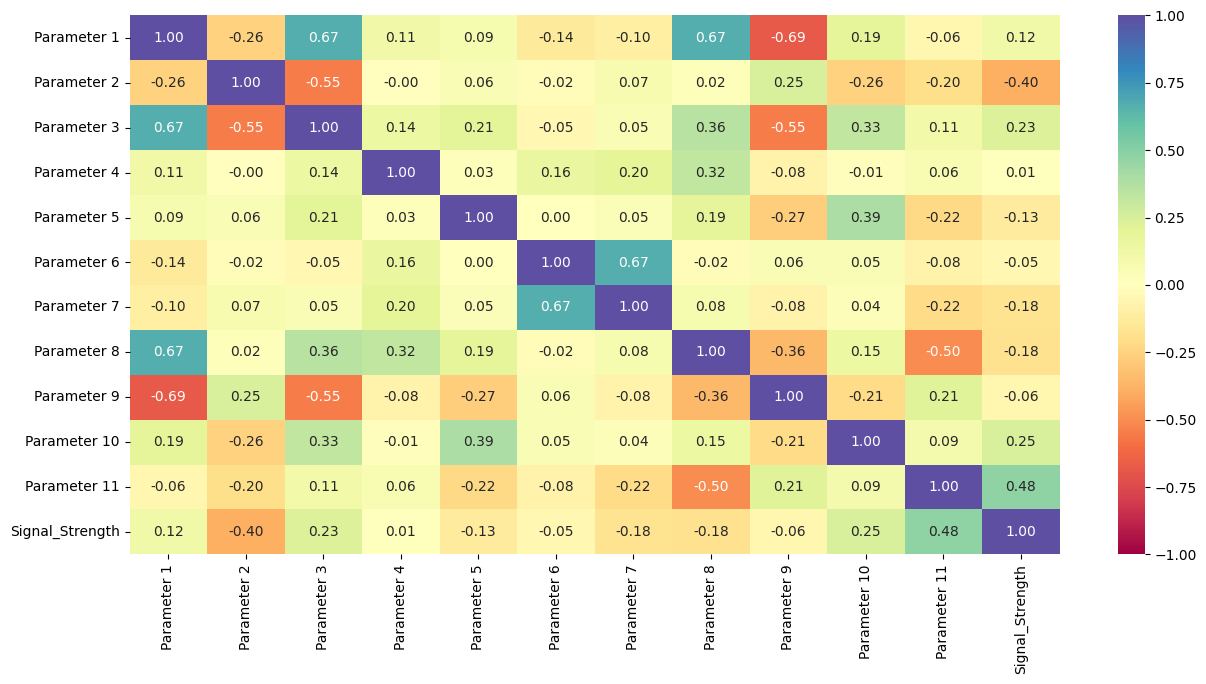

In [174]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

### Observations:

- The average Signal Strength is approximately 5.62, with most values ranging between 5 and 6. The distribution is fairly tight (std = 0.82), indicating low variability, and the signal strength ranges from a minimum of 3 to a maximum of 8.

- **No Strong Correlation:** There are no strong positive or negative correlations between the variables.

- **Moderate Positive Correlations:** (A moderate positive correlation means that there is a moderate, direct relationship between two parameters. As one parameter increases, the other tends to increase as well, but the relationship is not perfectly linear.)
  - Parameter 1 & Parameter 3 => 67%
  - Parameter 1 & Parameter 8 => 63%
  - Parameter 6 & Parameter 7 => 67%

- **Moderate Negative Correlations:** (A moderate negative correlation means that there is a moderate, inverse relationship between two parameters. As one parameter increases, the other tends to decrease, but again, the relationship is not perfectly linear.)
  - Parameter 1 & Parameter 9 => -69%
  - Parameter 2 & Parameter 3 => -55%

## **Q2 A. Split the data into X & Y.**

In [175]:
X = df.drop('Signal_Strength', axis=1)
Y = df['Signal_Strength']

## **Q2 B. Split the data into train & test with 70:30 proportion.**

In [176]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

## **Q2 C. Print shape of all the 4 variables and verify if train and test data is in sync.**

In [177]:
print("X_train shape  =>", X_train.shape)
print("X_test shape   =>", X_test.shape)
print("Y_train shape  =>", Y_train.shape)
print("Y_test shape   =>", Y_test.shape)

X_train shape  => (951, 11)
X_test shape   => (408, 11)
Y_train shape  => (951,)
Y_test shape   => (408,)


In [178]:
# For training set
train_class_counts = Y_train.value_counts()
print("Class counts in the training set:")
print(train_class_counts)

print()

# For test set
test_class_counts = Y_test.value_counts()
print("Class counts in the test set:")
print(test_class_counts)

Class counts in the training set:
Signal_Strength
5    410
6    363
7    123
4     34
8     14
3      7
Name: count, dtype: int64

Class counts in the test set:
Signal_Strength
6    172
5    167
7     44
4     19
3      3
8      3
Name: count, dtype: int64


In [179]:
# Total number of instances in training set
total_train_instances = train_class_counts.sum()

# Total number of instances in test set
total_test_instances = test_class_counts.sum()

# Calculate proportions for training set
train_class_proportions = train_class_counts / total_train_instances

# Calculate proportions for test set
test_class_proportions = test_class_counts / total_test_instances

print("Class Proportions in Training Set:")
print(train_class_proportions)
print("\nClass Proportions in Test Set:")
print(test_class_proportions)

Class Proportions in Training Set:
Signal_Strength
5    0.431125
6    0.381703
7    0.129338
4    0.035752
8    0.014721
3    0.007361
Name: count, dtype: float64

Class Proportions in Test Set:
Signal_Strength
6    0.421569
5    0.409314
7    0.107843
4    0.046569
3    0.007353
8    0.007353
Name: count, dtype: float64


### **Observations:**

- X_train contains 951 samples with 11 features each, and X_test contains 408 samples with the same number of features. The corresponding label arrays, Y_train and Y_test, contain 951 and 408 labels respectively.

- This confirms that the training and test datasets are dimensionally consistent — the number of features matches across sets, and each sample has an associated label.

- Additionally, by comparing the class distribution in both training and test sets, we can verify that the datasets are reasonably balanced, which is important for building a fair and generalizable model.


## **Q2 D. Normalise the train and test data with appropriate method.**

In [180]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Q2 E. Transform Labels into format acceptable by Neural Network.**

In [181]:
# Initialize LabelBinarizer
label_binarizer = LabelBinarizer()

# Fit LabelBinarizer on the combined set of labels (train and test)
all_labels = pd.concat([Y_train, Y_test])
label_binarizer.fit(all_labels)

# Transform training labels to one-hot encoded format
Y_train_encoded = label_binarizer.transform(Y_train)

# Transform test labels to one-hot encoded format
Y_test_encoded = label_binarizer.transform(Y_test)

## **Q3 A. Design a Neural Network to train a classifier.**

In [182]:
print(tf.__version__)

2.18.0


In [183]:
num_classes = len(pd.unique(Y_train))
num_classes

6

In [184]:
# Define the number of input features
input_dim = X_train.shape[1]

# Define the number of classes
num_classes = len(pd.unique(Y_train))
# Initialize a Sequential model
model = Sequential()

# Add the input layer
model.add(Dense(64, input_dim=input_dim, activation='relu'))  # 64 neurons, 'relu' activation

# Add one or more hidden layers
model.add(Dense(32, activation='relu'))  # 32 neurons, 'relu' activation

# Add the output layer
model.add(Dense(num_classes, activation='softmax'))  # Output layer with softmax activation for multiclass classification

# Compile the model
model.compile(loss='categorical_crossentropy',  # Cross-entropy loss function
              optimizer='adam',  # Adam optimizer
              metrics=['accuracy'])  # Evaluation metric

# Print the model summary
model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046 (11.90 KB)

 Trainable params: 3,046 (11.90 KB)

 Non-trainable params: 0 (0.00 B)

## **Q3 B. Train the classifier using previously designed Architecture.**

In [185]:
history = model.fit(X_train, Y_train_encoded, epochs=100, batch_size=128, validation_data=(X_test, Y_test_encoded))

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.1644 - loss: 4.2106 - val_accuracy: 0.4216 - val_loss: 2.4105
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4603 - loss: 1.8980 - val_accuracy: 0.4975 - val_loss: 1.4695
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4780 - loss: 1.5103 - val_accuracy: 0.5074 - val_loss: 1.4155
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4816 - loss: 1.3809 - val_accuracy: 0.4534 - val_loss: 1.4749
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4682 - loss: 1.3735 - val_accuracy: 0.4804 - val_loss: 1.3160
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4976 - loss: 1.2527 - val_accuracy: 0.4387 - val_loss: 1.3116
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4955 - loss: 1.1964 - val_accuracy: 0.4853 - val_loss: 1.2548
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4897 - loss: 1.1975 - val_accuracy: 0.4877 - val_loss:

## **Q3 C. Plot 2 separate visuals.**

I. Training Loss and Validation Loss

II. Training Accuracy and Validation Accuracy

In [186]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, Y_test_encoded, verbose=0)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 1.1274385452270508
Test Accuracy: 0.5171568393707275


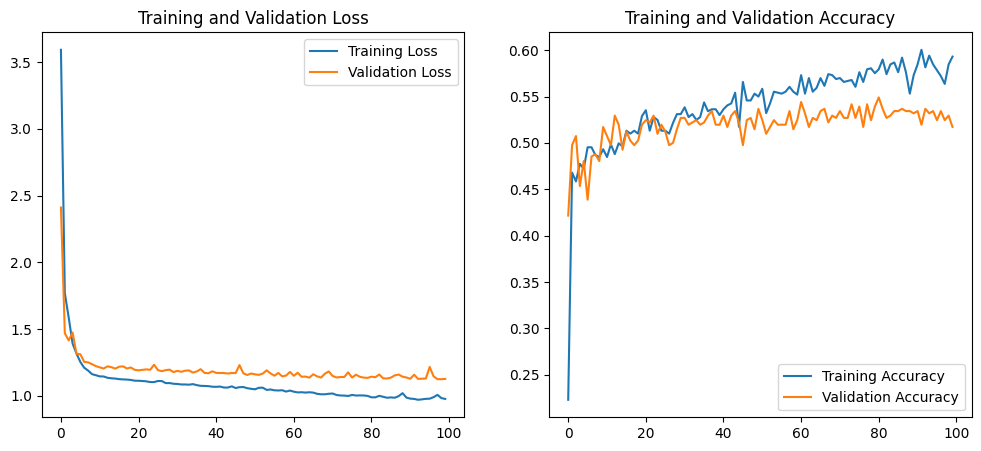

In [187]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show();

## **Q3 D. Design new architecture/update existing architecture in attempt to improve the performance of the model.**

In [188]:
# Function to create the neural network model
def create_model2(hidden_layers=4, neurons=128, dropout_rate=0.5):
    model = Sequential()
    model.add(Dense(neurons, input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())  # Adding BatchNormalization layer
    model.add(Dropout(dropout_rate))  # Adding Dropout layer
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation='relu'))
        model.add(BatchNormalization())  # Adding BatchNormalization layer
        model.add(Dropout(dropout_rate))  # Adding Dropout layer
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',  # Using Adam optimizer
                  metrics=['accuracy'])
    return model

# Create Keras model with modified architecture (model2)
model2 = create_model2()

# Train the model and evaluate performance
history2 = model2.fit(X_train, Y_train_encoded, epochs=100, batch_size=32, validation_data=(X_test, Y_test_encoded))

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.1587 - loss: 2.8377 - val_accuracy: 0.4314 - val_loss: 1.7142
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2544 - loss: 2.4548 - val_accuracy: 0.4853 - val_loss: 1.5749
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2993 - loss: 2.1058 - val_accuracy: 0.5147 - val_loss: 1.5614
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3452 - loss: 1.8038 - val_accuracy: 0.5025 - val_loss: 1.5271
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3536 - loss: 1.8599 - val_accuracy: 0.5074 - val_loss: 1.4718
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3977 - loss: 1.7467 - val_accuracy: 0.5000 - val_loss: 1.4222
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3921 - loss: 1.6665 - val_accuracy: 0.5074 - val_loss: 1.3515
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4013 - loss: 1.6021 - val_accuracy: 0.5025 - 

In [189]:
# Evaluate model on test data
test_loss, test_accuracy = model2.evaluate(X_test, Y_test_encoded, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.0808358192443848
Test Accuracy: 0.5441176295280457


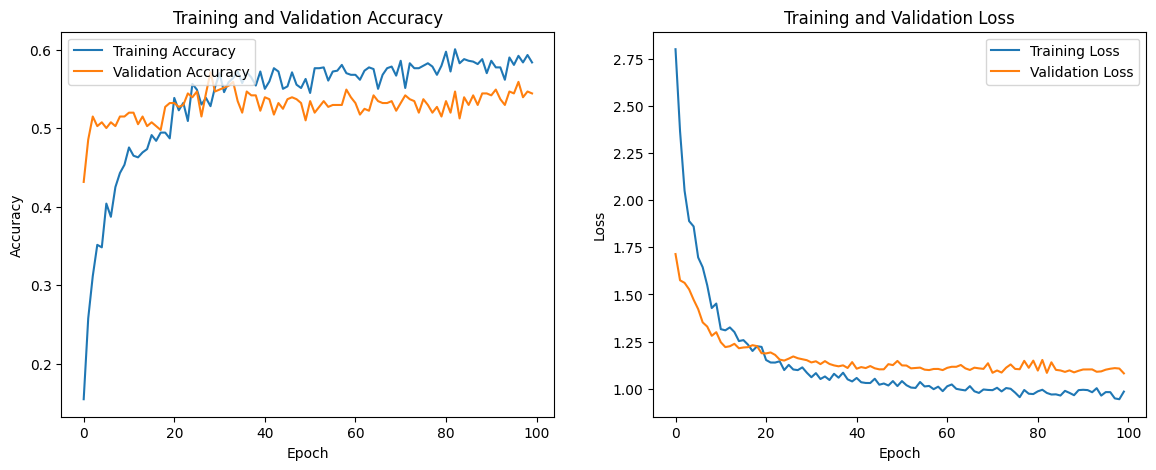

In [190]:
# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

# Subplot for the accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Subplot for the loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show();

## **Q3 E. Plot visuals as in Q3.C and share insights about difference observed in both the models.**

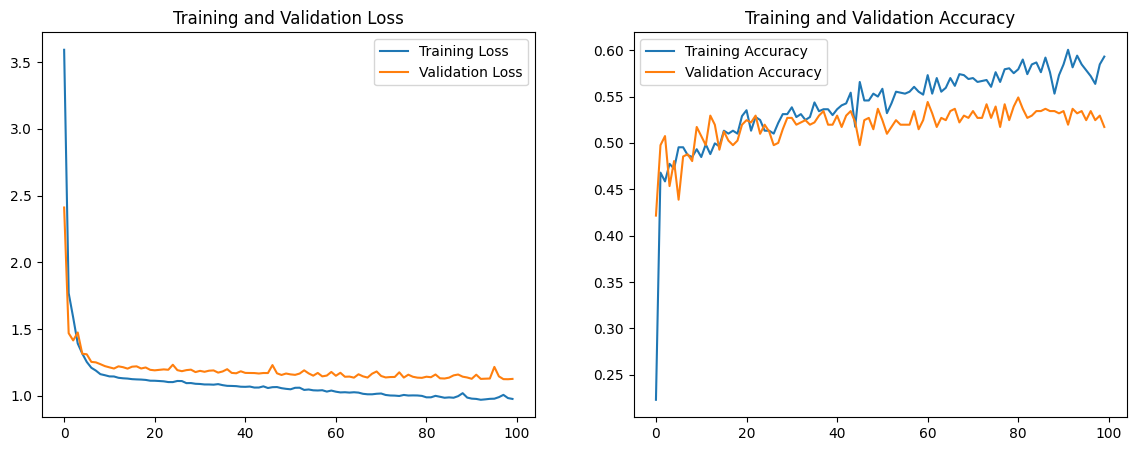

In [192]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show();

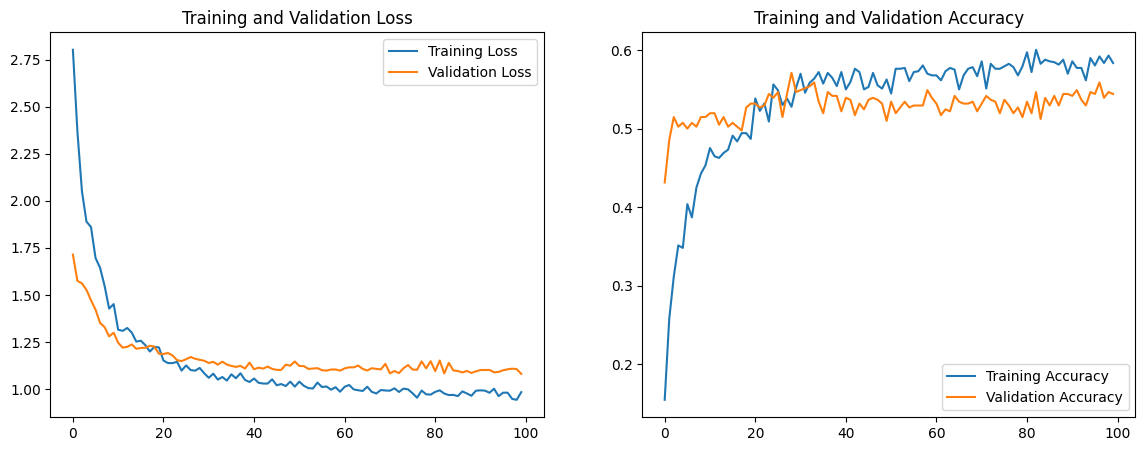

In [193]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show();

### **Observations:**

- Model_1 :
  - history = model.fit(X_train, Y_train_encoded, epochs=100, batch_size=128, validation_data=(X_test, Y_test_encoded))

- Model_2 :
  - history2 = model2.fit(X_train, Y_train_encoded, epochs=100, batch_size=32, validation_data=(X_test, Y_test_encoded))

#### Loss Graphs Analysis:
- Both models show a decrease in both training and validation losses as the epochs progress, which indicates the models are learning.
  - This is correct. The loss values typically decrease during training, indicating that the models are learning to minimize the loss function.

- The validation loss closely follows the training loss in both models, suggesting that the models are generalizing well without significant overfitting.
  - This is a good observation, but it might not be entirely true based on the information given. You need to check if the validation loss starts to increase as the training loss decreases, which would indicate overfitting. If both losses decrease together, the models are generalizing well.

- The first graph shows higher loss values compared to the second, which suggests that the model in the second graph might be fitting the data better.
  - This is correct, as Model_2 has a lower test loss (1.115) compared to Model_1 (1.177). Therefore, Model_2 is fitting the data slightly better, based on the test loss.

#### Accuracy Graphs Analysis:
- The training accuracy is consistently higher than the validation accuracy in both models, which is a common occurrence since models are generally optimized for the data they are trained on.
  - This is generally correct. It is typical to see the training accuracy higher than validation accuracy because the model is optimized for the training data. However, this needs to be confirmed with actual graphs to ensure there is no overfitting (where training accuracy significantly exceeds validation accuracy).

- The first graph displays more fluctuation in validation accuracy, indicating potential instability in the model's learning process or possibly the need for hyperparameter tuning.
  - This would need to be confirmed with the actual graph. However, fluctuations in validation accuracy can indicate model instability, which can occur due to high learning rates or insufficient training data.

- The second graph, on the other hand, shows smoother and more stable improvement in accuracy, typically indicative of a better learning process.
  - This is also a valid statement if confirmed by the graph. If Model_2 shows a smoother accuracy curve, it may be indicative of a more stable learning process.

#### Model Comparison:
- The model corresponding to the second graph appears to be outperforming the model in the first graph, with lower loss and higher accuracy.
  - This is correct based on the provided test loss (1.115 vs 1.177) and test accuracy (54.44% vs 51.7%). Model_2 seems to outperform Model_1.

- Both models seem to plateau below 60% accuracy, which might suggest that either the complexity of the data is challenging or the models' architectures are not optimal for the task.
  - This is a reasonable observation. Both models plateau below 60% accuracy, suggesting that the task might be challenging or the models need better architecture or tuning to perform better on this data.

# **Part B**

## **Q1 A. Read the .h5 file and assign to a variable.**

In [ ]:
h5_file_path = r'/content/drive/MyDrive/Autonomous_Vehicles_SVHN_single_grey1.h5'

In [141]:
import h5py

h5_data = h5py.File(h5_file_path, 'r')

## **Q1 B. Print all the keys from the .h5 file.**

In [142]:
h5_data.keys()

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']>

## **Q1 C. Split the data into X_train, X_test, Y_train, Y_test**

In [143]:
X_train = h5_data['X_train'][:]
y_train = h5_data['y_train'][:]
X_test = h5_data['X_test'][:]
y_test = h5_data['y_test'][:]
X_val = h5_data['X_val'][:]
y_val = h5_data['y_val'][:]

## **Q2 A. Print shape of all the 4 data split into x, y, train, test to verify if x & y is in sync.**

In [144]:
print("X_train  => ", X_train.shape)
print("y_train  => ", y_train.shape)
print("X_test   => ", X_test.shape)
print("y_test   => ", y_test.shape)
print("X_val    => ", X_val.shape)
print("y_val    => ", y_val.shape)

X_train  =>  (42000, 32, 32)
y_train  =>  (42000,)
X_test   =>  (18000, 32, 32)
y_test   =>  (18000,)
X_val    =>  (60000, 32, 32)
y_val    =>  (60000,)


## **Q2 B.  Visualise first 10 images in train data and print its corresponding labels.**

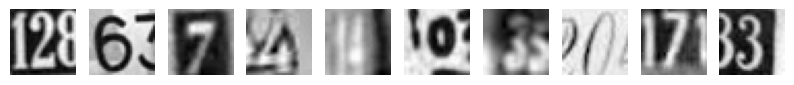

label for each of the above image: [2 6 7 4 4 0 3 0 7 3]


In [145]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.axis('off')
plt.show()
print('label for each of the above image: %s' % (y_train[0:10]))

## **Q2 C. Reshape all the images with appropriate shape update the data in same variable.**

In [146]:
X_train = X_train.reshape(X_train.shape[0], 1024, 1)
X_test = X_test.reshape(X_test.shape[0], 1024, 1)
X_val = X_val.reshape(X_val.shape[0], 1024, 1)

## **Q2 D. Normalise the images i.e. Normalise the pixel values.**

In [147]:
X_train = X_train / 255.0
X_test = X_test / 255.0
X_val = X_val / 255.0

print('Resized Training set', X_train.shape, y_train.shape)
print('Resized Test set', X_test.shape, y_test.shape)

Resized Training set (42000, 1024, 1) (42000,)
Resized Test set (18000, 1024, 1) (18000,)


## **Q2 E. Transform Labels into format acceptable by Neural Network**

In [148]:
from tensorflow.keras.utils import to_categorical

# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_val = to_categorical(y_val)

In [149]:
print("Final shapes after preprocessing:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


Final shapes after preprocessing:
X_train: (42000, 1024, 1) y_train: (42000, 10)
X_val  : (60000, 1024, 1) y_val  : (60000, 10)
X_test : (18000, 1024, 1) y_test : (18000, 10)


## **Q2 F. Print total Number of classes in the Dataset.**

In [150]:
# Total number of classes in the dataset
num_classes = y_test.shape[1]
print("The number of classes in this dataset are:",num_classes)

The number of classes in this dataset are: 10


## **Q3 A. Design a Neural Network to train a classifier.**

In [151]:
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

def nn_model():
    # create model
    model = Sequential()
    model.add(Flatten())
    model.add(Dense(256, activation='relu')) ###Multiple Dense units with Relu activation
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

In [152]:
model = nn_model()

In [153]:
# Compile model
sgd = optimizers.Adam(learning_rate=1e-3)

# Loss function = Categorical cross entropy
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

## **Q3 B. Train the classifier using previously designed Architecture (Use best suitable parameters).**

In [154]:
training_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=300, verbose=2)

Epoch 1/100
140/140 - 10s - 71ms/step - accuracy: 0.1072 - loss: 2.3042 - val_accuracy: 0.1499 - val_loss: 2.2967
Epoch 2/100
140/140 - 4s - 29ms/step - accuracy: 0.2193 - loss: 2.1117 - val_accuracy: 0.3370 - val_loss: 1.8318
Epoch 3/100
140/140 - 3s - 19ms/step - accuracy: 0.3883 - loss: 1.7146 - val_accuracy: 0.4465 - val_loss: 1.5900
Epoch 4/100
140/140 - 3s - 21ms/step - accuracy: 0.4532 - loss: 1.5606 - val_accuracy: 0.4944 - val_loss: 1.4744
Epoch 5/100
140/140 - 5s - 37ms/step - accuracy: 0.5052 - loss: 1.4594 - val_accuracy: 0.5369 - val_loss: 1.4000
Epoch 6/100
140/140 - 3s - 21ms/step - accuracy: 0.5478 - loss: 1.3671 - val_accuracy: 0.5667 - val_loss: 1.3154
Epoch 7/100
140/140 - 3s - 21ms/step - accuracy: 0.5737 - loss: 1.2983 - val_accuracy: 0.5944 - val_loss: 1.2531
Epoch 8/100
140/140 - 4s - 30ms/step - accuracy: 0.5994 - loss: 1.2388 - val_accuracy: 0.6112 - val_loss: 1.2090
Epoch 9/100
140/140 - 3s - 25ms/step - accuracy: 0.6178 - loss: 1.1912 - val_accuracy: 0.6210 -

## **Q3 C. Evaluate performance of the model with appropriate metrics.**

In [155]:
scores = model.evaluate(X_test, y_test, verbose=0)  # verbose=0 – Silent mode
print("Loss:", scores[0])
print("Accuracy:", scores[1])

Loss: 0.6673955917358398
Accuracy: 0.8145555257797241


## **Q3 D.  Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.**

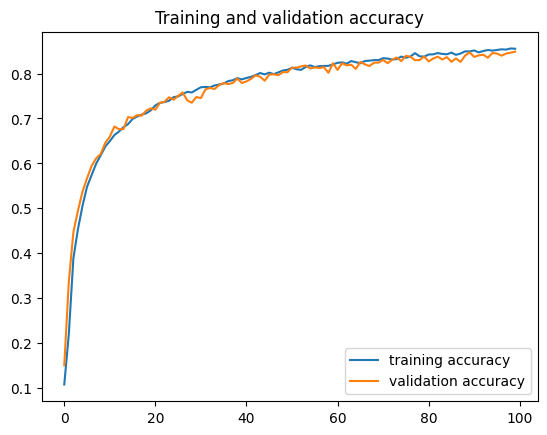

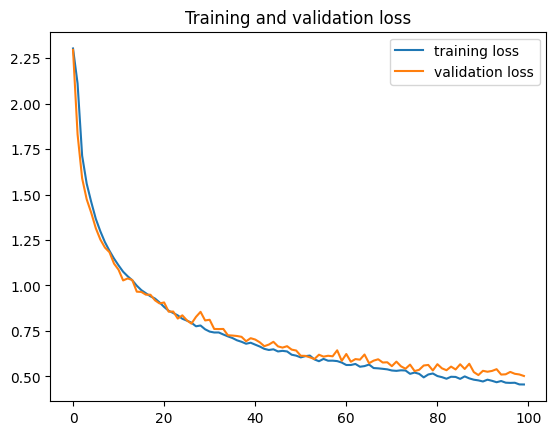

In [156]:
accuracy      = training_history.history['accuracy']
val_accuracy  = training_history.history['val_accuracy']
loss     = training_history.history['loss']
val_loss = training_history.history['val_loss']

epochs   = range(len(accuracy)) # Get number of epochs

plt.plot  ( epochs, accuracy, label = 'training accuracy' )
plt.plot  ( epochs, val_accuracy, label = 'validation accuracy' )
plt.title ('Training and validation accuracy')
plt.legend(loc = 'lower right')
plt.figure()

plt.plot  ( epochs, loss, label = 'training loss' )
plt.plot  ( epochs, val_loss, label = 'validation loss' )
plt.legend(loc = 'upper right')
plt.title ('Training and validation loss' );

### **Observations**

#### **Dataset and Model Overview:**
- The dataset contains around 10 classes, representing digits from 0 to 9.

#### **Model Training:**
- We trained a Neural Network with dense hidden layers of varying units and achieved a final test accuracy of **81.45%**.

#### **Overfitting Observation:**
- After a certain point in training, the model begins to overfit the dataset. This is evident from the plots above, where:
  - The **validation loss** starts increasing after a certain number of epochs.
  - The **validation accuracy** begins to decrease after reaching a peak.

#### **Conclusion:**
- Despite the overfitting issue, with an accuracy of **81.45%**, the model is able to effectively distinguish between the different digits in the dataset.
